# Introduction to Data Science 2026

# Week 6: Recap

## Exercise 1 | Linear regression with feature selection

Download the [TED Talks](https://www.kaggle.com/rounakbanik/ted-talks) dataset from Kaggle. Your task is to predict both the ratings and the number of views of a given TED talk. You should focus only on the <span style="font-weight: bold">ted_main</span> table.

1. Download the data, extract the following ratings from column <span style="font-weight: bold">ratings</span>: <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, <span style="font-weight: bold">Inspiring</span>. Store these values into respective columns so that they are easier to access. Next, extract the tags from column <span style="font-weight: bold">tags</span>. Count the number of occurrences of each tag and select the top-100 most common tags. Create a binary variable for each of these and include them in your data table, so that you can directly see whether a given tag (among the top-100 tags) is used in a given TED talk or not. The dataset you compose should have dimension (2550, 104), and comprise of the 'views' column, the three columns with counts of "Funny", "Confusing and "Inspiring" ratings, and 100 columns which one-hot encode the top-100 most common tag columns.


In [1]:
import pandas as pd
import numpy as np
import ast

ratings_categories = ['Funny', 'Confusing', 'Inspiring']

df = pd.read_csv('ted_main.csv')
# print(df.head())
edited_df = df.copy()
edited_df =edited_df.drop(columns=["comments", "description", "duration", "event", "film_date", "languages", "main_speaker", "name", "num_speaker", "published_date", "related_talks", "speaker_occupation", "title", "url"])

ratings = edited_df['ratings']
ratings = ratings.apply(ast.literal_eval)
exploded = ratings.explode()
normalised = pd.json_normalize(exploded)
normalised.index = exploded.index
normalised = normalised[normalised["name"].isin(ratings_categories)]
ratings = normalised.pivot_table(index=normalised.index, columns="name", values="count")

edited_df = edited_df.join(ratings)
edited_df = edited_df.drop(columns=["ratings"])
# print(edited_df.head())

tags = edited_df['tags']
tags = tags.apply(ast.literal_eval)
e = tags.explode()
counts = e.value_counts().head(100)
tags = e[e.isin(counts.index)]
dummies = pd.get_dummies(tags).groupby(level=0).max().astype(int).reindex(edited_df.index, fill_value=0)
edited_df = edited_df.drop(columns='tags').join(dummies)
print(edited_df.shape)
# print(edited_df.head())

(2550, 104)


2. Construct a linear regression model to predict the number of views based on the data in the <span style="font-weight: bold">ted_main</span> table, including the binary variables for the top-100 tags that you just created.

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def linear_regression(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression().fit(X_train, y_train)

    views_pred = model.predict(X_test)

    # The coefficients
    # print('Coefficients: \n', model.coef_)
    print('Mean squared error: %.2f'% mean_squared_error(y_test, views_pred))
    print('Coefficient of determination: %.2f'% model.score(X_test, y_test))
    return


y = df['views']
X =  df.join(edited_df.drop(columns='views')).select_dtypes(include='number').drop(columns=['views', 'Funny', 'Confusing', 'Inspiring'])
# print(X)
linear_regression(X,y)



Mean squared error: 4434456667921.02
Coefficient of determination: -0.14


3. Do the same for the <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, and <span style="font-weight: bold">Inspiring</span> ratings.

In [3]:
for word in ratings_categories:
    y = edited_df[word]
    linear_regression(X, y)
    

Mean squared error: 156630.49
Coefficient of determination: -0.17
Mean squared error: 842.29
Coefficient of determination: 0.07
Mean squared error: 1135779.47
Coefficient of determination: -0.24


4. You will probably notice that most of the tags are not useful in predicting the views and the ratings. You should use some kind of variable selection to prune the set of tags that are included in the model. You can use for example classical p-values or more modern [LASSO](https://en.wikipedia.org/wiki/Lasso_(statistics)) techniques. Which tags are the best predictors of each of the response variables?

In [4]:
from sklearn.linear_model import LassoCV


def lasso(X,y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    reg = LassoCV(cv=5, random_state=0).fit(X_train, y_train)
    print('alpha: %.4f  test R2: %.3f' % (reg.alpha_, reg.score(X_test, y_test)))
    # print(reg.coef_)
    
    return reg.coef_


5. Produce summaries of your results. Could you recommend good tags – or tags to avoid! – for speakers targeting plenty of views and/or certain ratings?

In [5]:
targets = ['Funny', 'Confusing', 'Inspiring', 'views']
for i in targets:
    y = edited_df[i]
    coef = lasso(dummies,y)
    coefs = pd.DataFrame(coef, index=dummies.columns, columns=[i])
    coefs = coefs[coefs[i] != 0].sort_values(by=i, key=abs, ascending=False)
    print(coefs.head(10))

alpha: 1.9097  test R2: 0.268
                    Funny
humor          791.631556
work           234.067727
creativity     175.083705
mind           154.195069
children       152.088129
neuroscience  -127.691748
entertainment  123.540971
psychology     113.232709
culture        110.188199
motivation     105.508401
alpha: 0.0841  test R2: 0.185
               Confusing
physics        14.698611
evolution      13.561845
philosophy     11.981538
religion       10.358914
brain          10.277819
psychology      8.678289
culture         8.376074
Africa         -6.908105
innovation     -6.524948
entertainment   6.402305
alpha: 5.6383  test R2: 0.111
                Inspiring
mental health  685.417259
psychology     630.336450
work           619.973176
education      479.083704
happiness      361.331652
creativity     358.661341
motivation     332.561318
economics     -320.345497
neuroscience  -298.951925
business       295.538974
alpha: 9312.0812  test R2: 0.174
                      views
ps

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Symbol classification (part 2)

Note that it is strongly recommended to use Python in this exercise. However, if you can find a suitable AutoML implementation for your favorite language (e.g [here](http://h2o-release.s3.amazonaws.com/h2o/master/3888/docs-website/h2o-docs/automl.html) seems to be one for R) then you are free to use that language as well.

Use the preprocessed data from week 3 (you can also produce them using the example solutions of week 3).

1. This time train a *random forest classifier* on the data. A random forest is a collection of *decision trees*, which makes it an *ensemble* of classifiers. Each tree uses a random subset of the features to make its prediction. Without tuning any parameters, how is the accuracy?

In [6]:
import cv2

df = pd.read_csv('HASYv2/hasy-data-labels.csv')

# print(df.head())
df = df[(df['symbol_id'] >= 70) &(df['symbol_id' ] <= 79 )]

images = []

# print(df.head())
for index, row in df.iterrows():
    img = str(row['path'])
    image = cv2.imread(f'HASYv2/{img}', cv2.IMREAD_GRAYSCALE)
    image = image.flatten()
    images.append(image)
    
images = np.array(images) 
labels = df['latex']

# print(labels.shape)
# print(images.shape)

test_size = 0.20

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=test_size, shuffle=True)

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test) # predict
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.8529411764705882


2. The amount of trees to use as a part of the random forest is an example of a hyperparameter, because it is a parameter that is set prior to the learning process. In contrast, a parameter is a value in the model that is learned from the data. Train 20 classifiers, with varying amounts of decision trees starting from 10 up until 200, and plot the test accuracy as a function of the amount of classifiers. Does the accuracy keep increasing? Is more better?

{10: 0.7450980392156863, 20: 0.7941176470588235, 30: 0.803921568627451, 40: 0.8235294117647058, 50: 0.8431372549019608, 60: 0.8480392156862745, 70: 0.8284313725490197, 80: 0.8627450980392157, 90: 0.8529411764705882, 100: 0.8676470588235294, 110: 0.8431372549019608, 120: 0.8578431372549019, 130: 0.8627450980392157, 140: 0.8627450980392157, 150: 0.8382352941176471, 160: 0.8480392156862745, 170: 0.8578431372549019, 180: 0.8627450980392157, 190: 0.8578431372549019, 200: 0.8431372549019608}


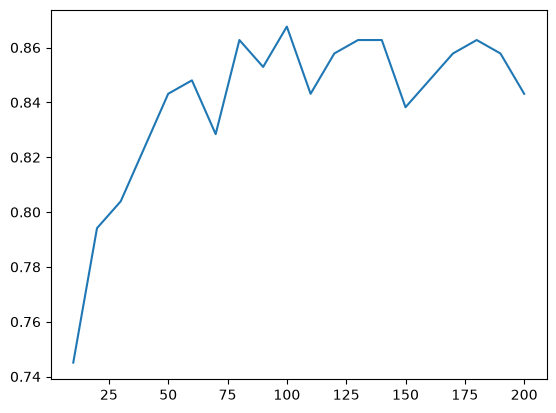

In [8]:
def forest(n):
    classifier = RandomForestClassifier(n_estimators=n)
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test) # predict
    acc = metrics.accuracy_score(y_test, y_pred)
    return acc

n = np.linspace(10, 200, num=20)
accuracy = {}

for i in n:
    i = int(i)
    result = forest(i)
    accuracy[i] = result
    
print(accuracy)

import matplotlib.pyplot as plt

x = list(accuracy.keys())
y = list(accuracy.values())

plt.plot(x, y)
plt.show()


3. If we had picked the amount of decision trees by taking the value with the best test accuracy from the last plot, we would have *overfit* our hyperparameters to the test data. Can you see why it is a mistake to tune hyperparameters of your model by using the test data?

Using the accuracy score to decide how many trees the forest should have is a bad idea because the final accuracy score can become optimistically bias (just because the accuracy is high for test doesnt mean its high for new unseen data). The test set should remain unseen to test the training data. 

4. Reshuffle and resplit the data so that it is divided in 3 parts: training (80%), validation (10%) and test (10%). Repeatedly train a model of your choosing (e.g random forest) on the training data, and evaluate it’s performance on the validation set, while tuning the hyperparameters so that the accuracy on the validation set increases. Then, finally evaluate the performance of your model on the test data. What can you say in terms of the generalization of your model?

{10: 0.7450980392156863, 20: 0.8137254901960784, 30: 0.8333333333333334, 40: 0.8333333333333334, 50: 0.8333333333333334, 60: 0.8725490196078431, 70: 0.8725490196078431, 80: 0.8627450980392157, 90: 0.8627450980392157, 100: 0.8627450980392157, 110: 0.8627450980392157, 120: 0.8823529411764706, 130: 0.8627450980392157, 140: 0.8823529411764706, 150: 0.8627450980392157, 160: 0.8431372549019608, 170: 0.8823529411764706, 180: 0.8823529411764706, 190: 0.8627450980392157, 200: 0.8823529411764706}


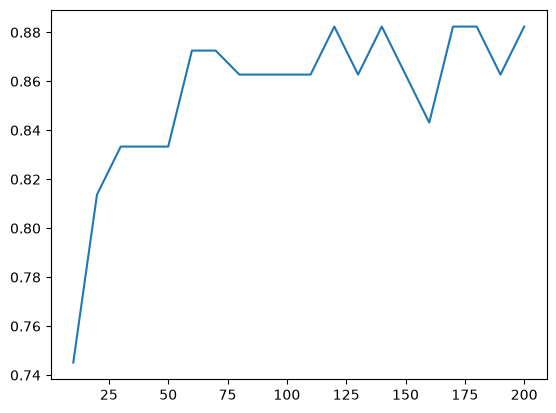

In [9]:

X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels, shuffle=True)   
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)  


accuracy = {}
for i in n:
    classifier = RandomForestClassifier(n_estimators=int(i))
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_val) # predict
    acc = metrics.accuracy_score(y_val, y_pred)
    accuracy[int(i)] = acc

print(accuracy)
x = list(accuracy.keys())
y = list(accuracy.values())

plt.plot(x, y)
plt.show()

In [10]:
final = RandomForestClassifier(n_estimators=100,  random_state=0)
final.fit(X_train, y_train)
y_pred = final.predict(X_test)


print('test:', metrics.accuracy_score(y_test, y_pred))

test: 0.8529411764705882


**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | TPOT

The process of picking a suitable model, evaluating its performance and tuning the hyperparameters is very time consuming. A new idea in machine learning is the concept of automating this by using an optimization algorithm to find the best model in the space of models and their hyperparameters. Have a look at [TPOT](https://github.com/EpistasisLab/tpot), an automated ML solution that finds a good model and a good set of hyperparameters automatically. Try it on this data, it should outperform simple models like the ones we tried easily. Note that running the algorithm might take a while, depending on the strength of your computer. 

*Note*: In case it is running for too long, try checking if the parameters you are using when calling TPOT are reasonable, i.e. try reducing number of ‘generations’ or ‘population_size’. TPOT uses cross-validation internally, so we don’t need our own validation set.

In [11]:
import tpot

est = tpot.TPOTClassifier(
    max_time_mins=10,              
)
est.fit(X_train,y_train)

print(est.fitted_pipeline_)
y_pred = est.predict(X_val)
print('accuracy:', metrics.accuracy_score(y_val.astype(int), y_pred.astype(int)))


/home/csimona/Documents/DS/Intro-to-DataScience/.venv/lib/python3.12/site-packages/stopit/__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/csimona/Documents/DS/Intro-to-DataScience/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/csimona/Documents/DS/Intro-to-DataScience/.venv/lib/python3.12/site-packages/tpot/tpot_estimator/estimator.py:537: UserWarning: Labels are not encoded as ints from 0 to N. For compatibility with some classifiers such as sklearn, TPOT has encoded y with the sklearn LabelEncoder. When using pipelines outside the main TPOT estimator cla

Pipeline(steps=[('normalizer', Normalizer(norm=np.str_('l2'))),
                ('selectpercentile',
                 SelectPercentile(percentile=85.4000833449182)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',
                                                 FeatureUnion(transformer_list=[('columnonehotencoder',
                                                                                 ColumnOneHotEncoder())])),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('mlpclassifier',
                 MLPClassifier(activation=np.str_('l

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**